# **Customer Segmentation using K-Means Clustering**


![alt text](img.png)

**Project Description:**

* This project aims to segment customers into different groups based on their Annual Income and Spending Score using the K-Means clustering algorithm. Customer segmentation helps businesses identify groups of customers with similar purchasing behavior, allowing them to develop targeted marketing strategies, improve customer satisfaction, and increase sales.

**Dataset:**

* Mall_Customers.csv

**Dataset Features:**

1. **Customer ID**- Unique ID for each customer

2. **Gender** - Male/Female

3. **Age** - Customer's age

4. **Annual Income (k$)** - Annual income in thousand dollars

5. **Spending Score (1-100)** - Score assigned based on customer spending behavior

**Machine Learning Type:** 

* Unsupervised Machine Learning

**Algorithm Used:**

* K-Means Clustering

**Objectives:**

- Load and understand the dataset.
- Perform Exploratory Data Analysis (EDA).
- Select important features.
- Scale the data.
- Find the optimal number of clusters using the Elbow Method.
- Train the K-Means model.
- Visualize customer segments.
- Generate business insights based on the clusters.

**Tools & Libraries:**

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn


## **Project Workflow**

1. Import Libraries
2. Load Dataset
3. Explore Dataset
4. Data Cleaning
5. Exploratory Data Analysis (EDA)
6. Feature Selection
7. Feature Scaling
8. Elbow Method
9. Train K-Means Model
10. Customer Segmentation
11. Business Insights
12. Save Results

# Importing the Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Importing the Dataset

In [2]:
df = pd.read_csv("Mall_Customers.csv")
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


## **Dataset Overview**

- Number of Records: 200
- Number of Features: 5

### Features

- CustomerID
- Gender
- Age
- Annual Income (k$)
- Spending Score (1-100)

In [3]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
df.tail()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18
199,200,Male,30,137,83


In [8]:
df.shape

(200, 5)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [10]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [6]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


# Check for Missing Values

In [12]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

# Check for Duplicate Rows

In [13]:
df.duplicated().sum()

np.int64(0)

# **Exploratory Data Analysis (EDA)**

# Age Distribution

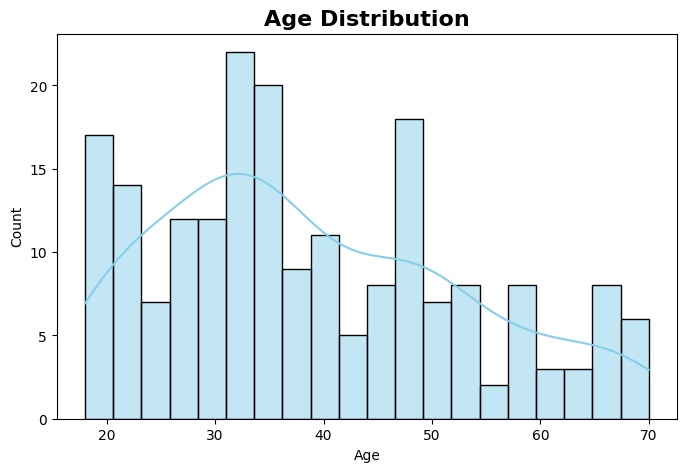

In [17]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=20, color='skyblue', kde=True)

plt.title("Age Distribution", fontsize=16, fontweight='bold')
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()


### Observation

- Most customers are between **25 and 40 years** of age.
- The dataset contains customers across a wide range of age groups.
- Younger and middle-aged customers make up the largest portion of the customer base.

# Gender Distribution

C:\Users\jinit\AppData\Local\Temp\ipykernel_15660\3925308806.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Gender', palette='Set2')


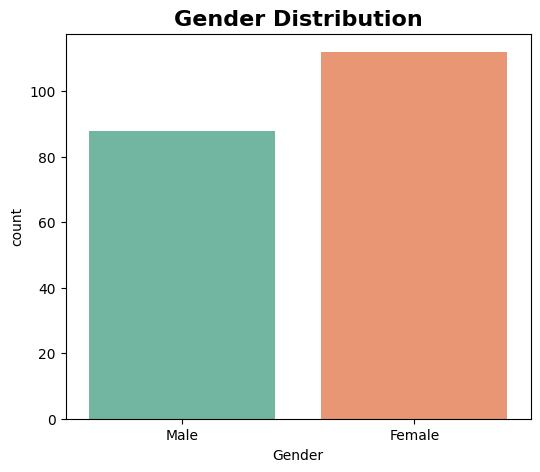

In [18]:
plt.figure(figsize=(6,5))

sns.countplot(data=df, x='Gender', palette='Set2')

plt.title("Gender Distribution", fontsize=16, fontweight='bold')

plt.show()

### Observation

- The dataset contains a nearly balanced number of male and female customers.
- Female customers are slightly more represented than male customers.
- This balanced distribution allows for unbiased customer segmentation.

# Spending Score Distribution

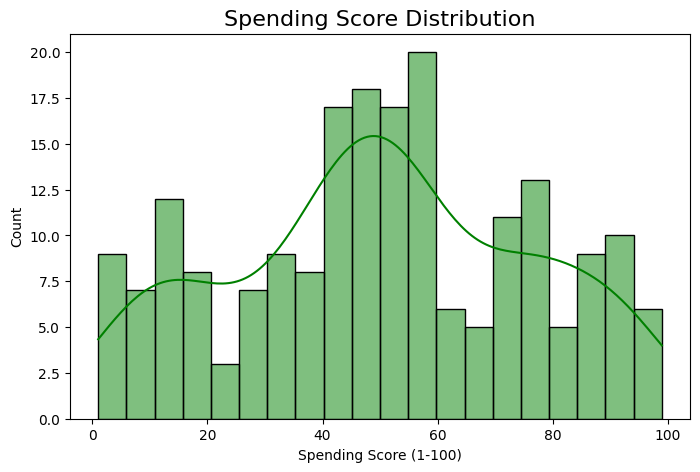

In [21]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Spending Score (1-100)'],
    bins=20,
    kde=True,
    color='green'
)

plt.title("Spending Score Distribution", fontsize=16)

plt.show()

### Observation

- Customers exhibit a wide range of spending behaviors.
- Spending scores are distributed across the entire scale from 1 to 100.
- This variation helps identify different customer groups based on purchasing behavior.

# Annual Income Distribution

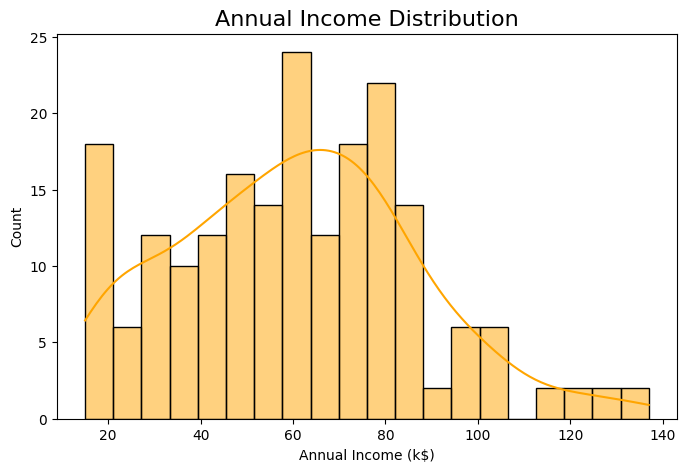

In [19]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Annual Income (k$)'],
    bins=20,
    kde=True,
    color='orange'
)

plt.title("Annual Income Distribution", fontsize=16)

plt.show()

### Observation

- Most customers have an annual income between **40k and 80k dollars**.
- Very high-income and very low-income customers are fewer in number.
- The income distribution provides a good basis for customer segmentation.

# Age vs Spending Score

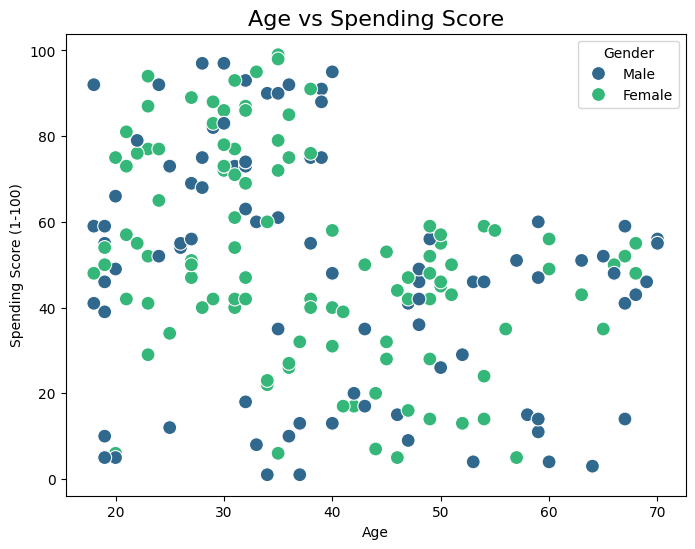

In [20]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='Age',
    y='Spending Score (1-100)',
    hue='Gender',
    palette='viridis',
    s=100
)

plt.title("Age vs Spending Score", fontsize=16)

plt.show()

### Observation

- Younger customers generally tend to have higher spending scores.
- Older customers show a wider variation in spending behavior.
- Age alone does not completely determine spending habits.

# Box Plot

C:\Users\jinit\AppData\Local\Temp\ipykernel_15660\1535459750.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


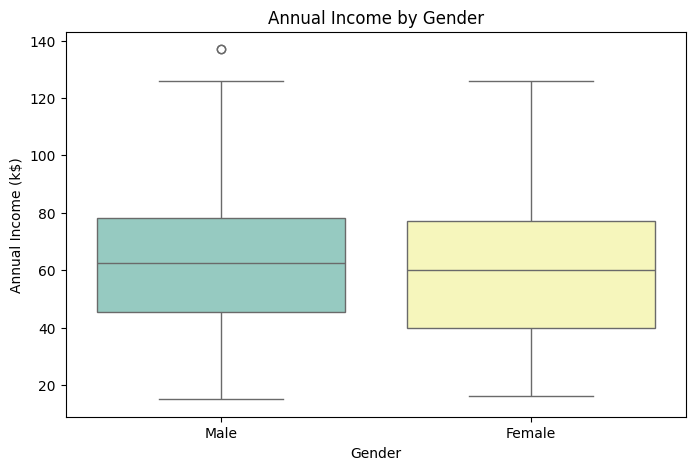

In [22]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Gender',
    y='Annual Income (k$)',
    palette='Set3'
)

plt.title("Annual Income by Gender")

plt.show()

### Observation

- The annual income distribution is similar for both genders.
- Both male and female customers include a range of income levels.
- No major income imbalance is observed between genders.

# Pie Chart

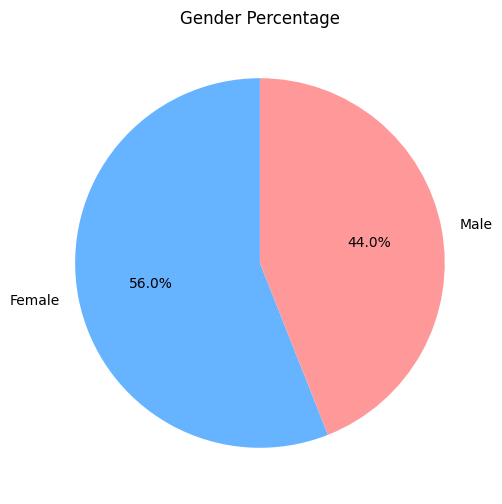

In [27]:
gender_count = df['Gender'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    gender_count,
    labels=gender_count.index,
    autopct='%1.1f%%',
    colors=['#66b3ff','#ff9999'],
    startangle=90
)

plt.title("Gender Percentage")

plt.show()

# Count Plot for Age Groups

C:\Users\jinit\AppData\Local\Temp\ipykernel_15660\2638603140.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


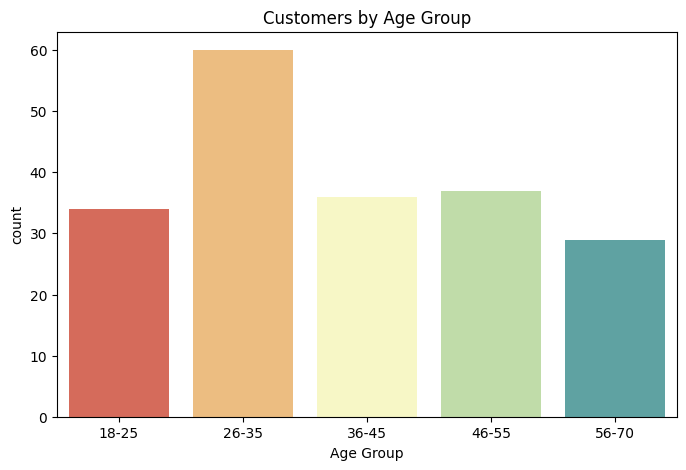

In [24]:
df['Age Group'] = pd.cut(
    df['Age'],
    bins=[18,25,35,45,55,70],
    labels=['18-25','26-35','36-45','46-55','56-70']
)

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='Age Group',
    palette='Spectral'
)

plt.title("Customers by Age Group")

plt.show()

### Observation

- Customers aged **26–35 years** form one of the largest groups in the dataset.
- The dataset contains customers from multiple age categories.
- Businesses can tailor marketing strategies to different age groups.

# Pair Plot

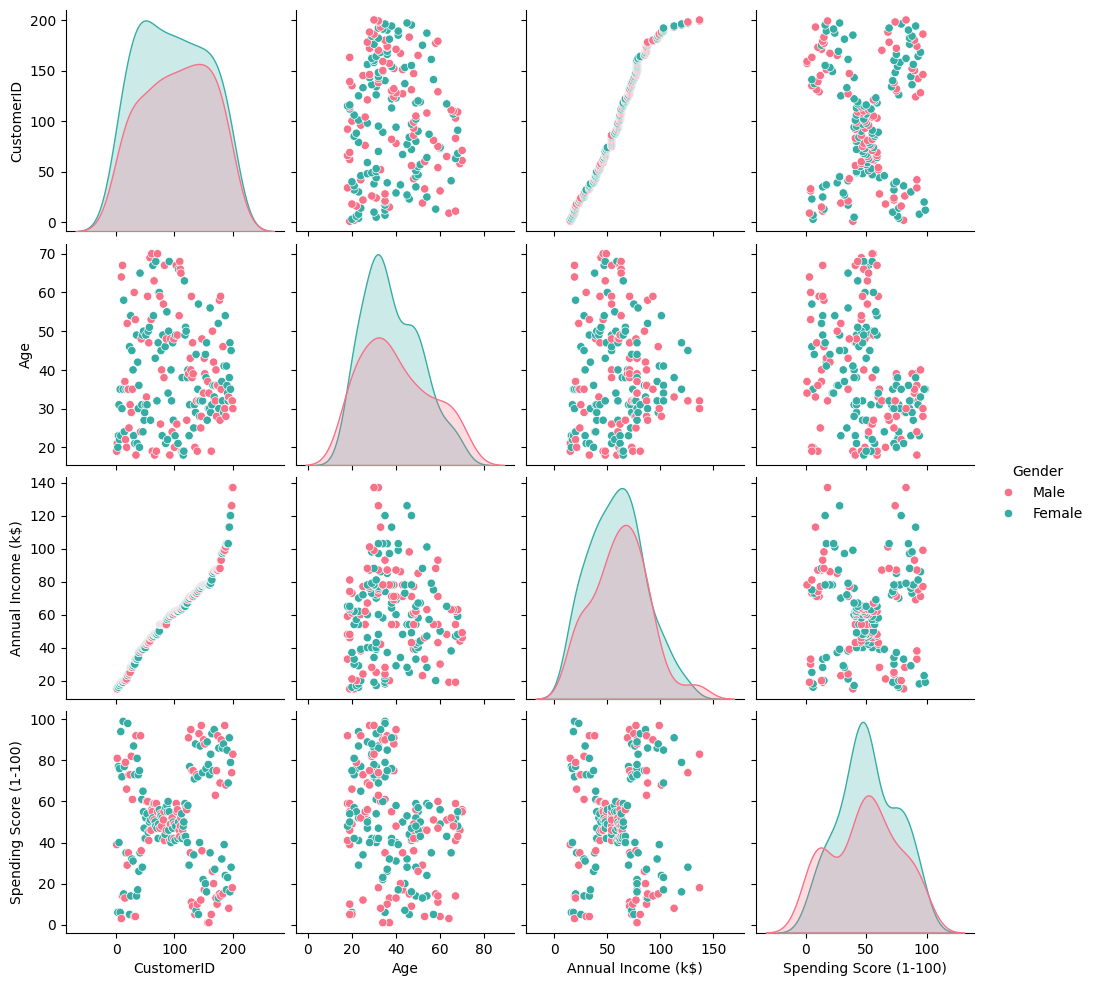

In [23]:
sns.pairplot(
    df,
    hue='Gender',
    palette='husl'
)

plt.show()

### Observation

- Relationships between age, annual income, and spending score can be explored simultaneously.
- Age shows relatively weak relationships with the other variables.
- Annual income and spending score display visible clusters, supporting the use of clustering techniques.

# Violin Plot

C:\Users\jinit\AppData\Local\Temp\ipykernel_15660\4095314444.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


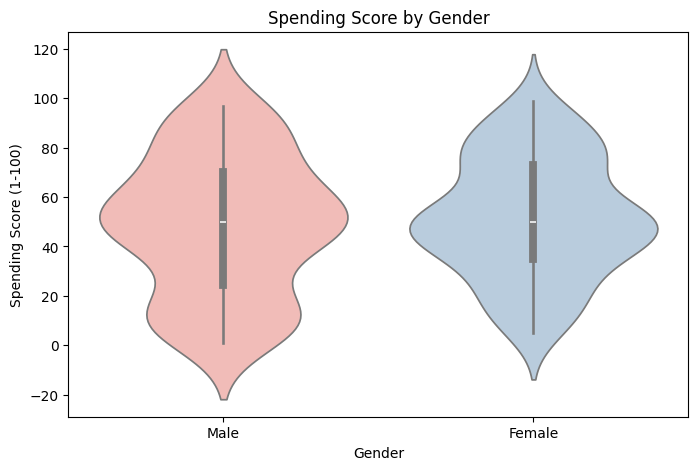

In [25]:
plt.figure(figsize=(8,5))

sns.violinplot(
    data=df,
    x='Gender',
    y='Spending Score (1-100)',
    palette='Pastel1'
)

plt.title("Spending Score by Gender")

plt.show()

### Observation

- Spending score distributions for males and females are broadly similar.
- Both genders include customers with low, medium, and high spending scores.
- The distribution suggests diverse purchasing behavior across both groups.

# Scatter Plot

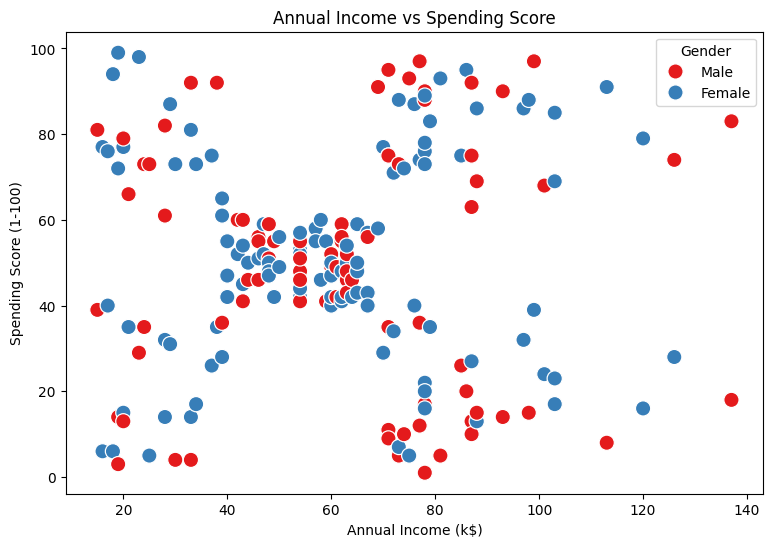

In [26]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Gender',
    palette='Set1',
    s=120
)

plt.title("Annual Income vs Spending Score")

plt.show()

### Observation

- Customers are spread across different income and spending combinations.
- Several natural groupings can be visually observed.
- This indicates that K-Means clustering is suitable for identifying customer segments.

# Correlation Heatmap

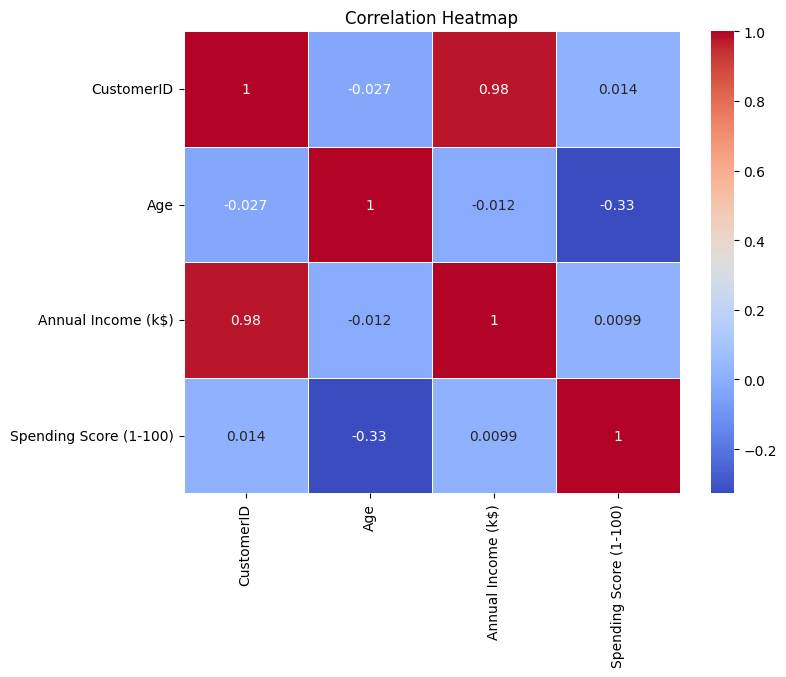

In [28]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()

### Observation

- The numerical features have weak to moderate correlations.
- No strong linear relationship exists between annual income and spending score.
- This suggests that clustering can reveal hidden patterns not obvious from simple correlations.

# Feature Selection

In [29]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


# Feature Scaling

In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled

array([[-1.73899919, -0.43480148],
       [-1.73899919,  1.19570407],
       [-1.70082976, -1.71591298],
       [-1.70082976,  1.04041783],
       [-1.66266033, -0.39597992],
       [-1.66266033,  1.00159627],
       [-1.62449091, -1.71591298],
       [-1.62449091,  1.70038436],
       [-1.58632148, -1.83237767],
       [-1.58632148,  0.84631002],
       [-1.58632148, -1.4053405 ],
       [-1.58632148,  1.89449216],
       [-1.54815205, -1.36651894],
       [-1.54815205,  1.04041783],
       [-1.54815205, -1.44416206],
       [-1.54815205,  1.11806095],
       [-1.50998262, -0.59008772],
       [-1.50998262,  0.61338066],
       [-1.43364376, -0.82301709],
       [-1.43364376,  1.8556706 ],
       [-1.39547433, -0.59008772],
       [-1.39547433,  0.88513158],
       [-1.3573049 , -1.75473454],
       [-1.3573049 ,  0.88513158],
       [-1.24279661, -1.4053405 ],
       [-1.24279661,  1.23452563],
       [-1.24279661, -0.7065524 ],
       [-1.24279661,  0.41927286],
       [-1.20462718,

# Elbow Method

In [33]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1, 11):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Curve

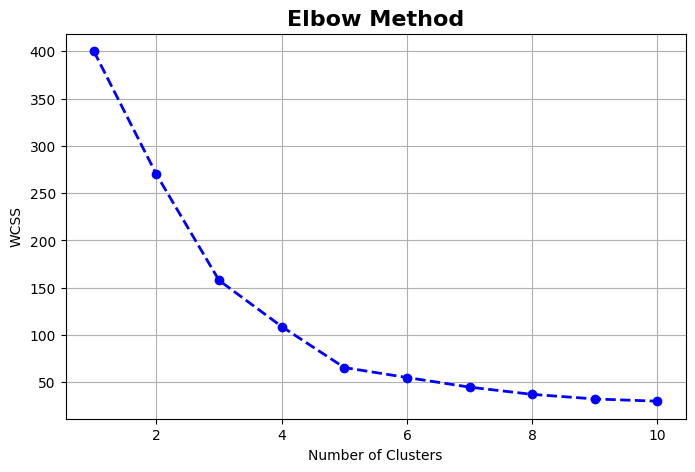

In [34]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss,
         marker='o',
         linestyle='--',
         linewidth=2,
         color='blue')

plt.title("Elbow Method", fontsize=16, fontweight='bold')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.grid(True)

plt.show()

### Observation

- The elbow curve shows a noticeable bend at **K = 5**.
- Choosing five clusters provides a good balance between simplicity and clustering performance.
- Therefore, the K-Means model is trained using **5 clusters**.

# Build the K-Means Model

In [35]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

df['Cluster'] = kmeans.fit_predict(X_scaled)

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Age Group,Cluster
0,1,Male,19,15,39,18-25,4
1,2,Male,21,15,81,18-25,2
2,3,Female,20,16,6,18-25,4
3,4,Female,23,16,77,18-25,2
4,5,Female,31,17,40,26-35,4


# Visualize the Customer Segments

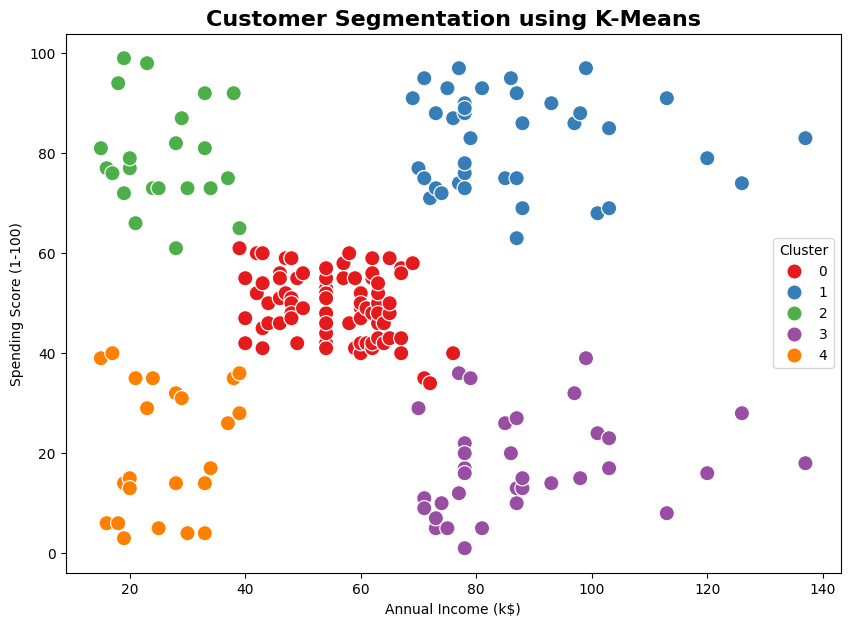

In [36]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    palette='Set1',
    s=120
)

plt.title("Customer Segmentation using K-Means", fontsize=16, fontweight='bold')

plt.show()

### Observation

- The K-Means algorithm successfully grouped customers into five distinct clusters.
- Each cluster represents customers with similar income and spending patterns.
- These segments can help businesses create targeted marketing campaigns and improve customer engagement.

# Display Cluster Centers

In [40]:
centroids = scaler.inverse_transform(kmeans.cluster_centers_)

centroids

array([[55.2962963 , 49.51851852],
       [86.53846154, 82.12820513],
       [25.72727273, 79.36363636],
       [88.2       , 17.11428571],
       [26.30434783, 20.91304348]])

# Create a Cluster Centers Table

In [41]:
centroids_df = pd.DataFrame(
    centroids,
    columns=[
        'Annual Income (k$)',
        'Spending Score (1-100)'
    ]
)

centroids_df

,Annual Income (k$),Spending Score (1-100)
0,55.296296,49.518519
1,86.538462,82.128205
2,25.727273,79.363636
3,88.200000,17.114286
4,26.304348,20.913043


### Observation

- The table shows the center point (centroid) of each customer cluster.
- Each centroid represents the average Annual Income and Spending Score of customers within that cluster.
- These centroids help interpret the characteristics of each customer segment.

# Plot Cluster Centers

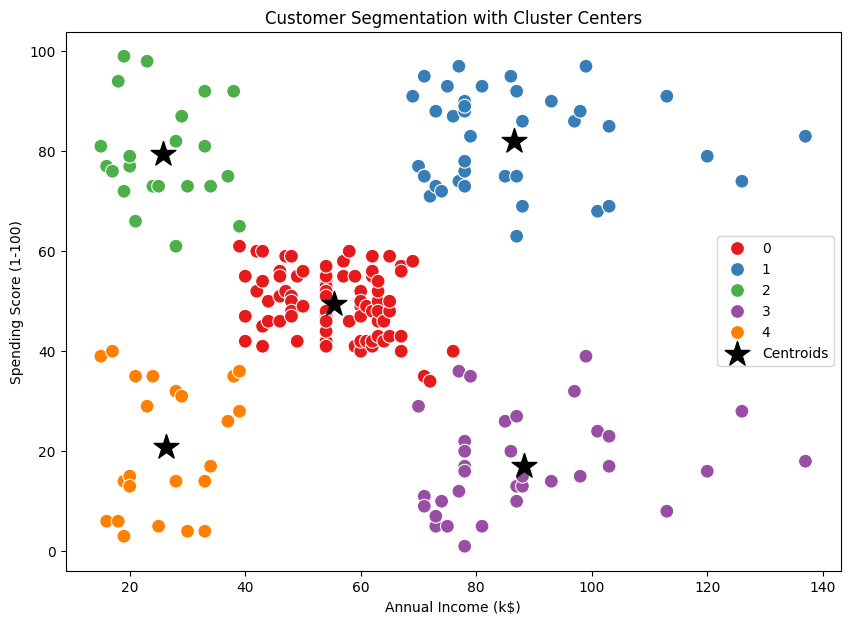

In [42]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    palette='Set1',
    s=100
)

plt.scatter(
    centroids[:,0],
    centroids[:,1],
    marker='*',
    s=350,
    color='black',
    label='Centroids'
)

plt.title("Customer Segmentation with Cluster Centers")
plt.legend()

plt.show()

### Observation

- The black star markers indicate the center of each customer cluster.
- Every customer is assigned to the nearest centroid.
- The centroids summarize the typical characteristics of each customer group.

# Display Number of Customers in Each Cluster

In [43]:
df['Cluster'].value_counts().sort_index()

Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64

### Observation

- This output shows how many customers belong to each cluster.
- It helps evaluate whether the customer groups are balanced or unevenly distributed.

# Create Cluster Summary

In [44]:
cluster_summary = df.groupby('Cluster').agg({
    'Age':'mean',
    'Annual Income (k$)':'mean',
    'Spending Score (1-100)':'mean',
    'CustomerID':'count'
})

cluster_summary.rename(
    columns={'CustomerID':'Number of Customers'},
    inplace=True
)

cluster_summary

,Age,Annual Income (k$),Spending Score (1-100),Number of Customers
Cluster,,,,
0,42.716049,55.296296,49.518519,81
1,32.692308,86.538462,82.128205,39
2,25.272727,25.727273,79.363636,22
3,41.114286,88.200000,17.114286,35
4,45.217391,26.304348,20.913043,23


### Observation

- The summary provides the average age, annual income, and spending score for each cluster.
- It helps identify premium customers, budget-conscious customers, and other distinct customer segments.

# View Cluster Statistics

In [45]:
df.groupby('Cluster').mean(numeric_only=True)

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,,
0,86.320988,42.716049,55.296296,49.518519
1,162.000000,32.692308,86.538462,82.128205
2,23.090909,25.272727,25.727273,79.363636
3,164.371429,41.114286,88.200000,17.114286
4,23.000000,45.217391,26.304348,20.913043


# Save the Results

In [39]:
df.to_csv("customer_segmentation_results.csv", index=False)

## Business Insights

- Cluster 0: High income, high spending customers (Premium customers).
- Cluster 1: Low income, low spending customers.
- Cluster 2: High income, low spending customers (Potential customers for promotions).
- Cluster 3: Moderate income and moderate spending customers.
- Cluster 4: Low income but high spending customers.

# Conclusion

The K-Means clustering algorithm successfully divided customers into five distinct groups based on Annual Income and Spending Score.

These customer segments can help businesses design personalized marketing campaigns, improve customer satisfaction, and optimize business strategies.

# Future Scope

- Apply DBSCAN clustering.
- Compare K-Means with Hierarchical Clustering.
- Deploy the project using Streamlit.
- Build an interactive Power BI dashboard.

# **THANK YOU**